# **Tìm hiểu các tính năng và cách sử dụng sản phẩm AutoViz áp dụng trên tập dữ liệu Marketing Campaign**

## **Giới thiệu AutoViz**
- AutoViz là một thư viện Python giúp tự động hóa quá trình trực quan hóa dữ liệu (EDA – Exploratory Data Analysis) với ít dòng code nhất. 

- Nó có thể nhận đầu vào là một file (CSV, txt, JSON) hoặc một pandas.DataFrame. 

- AutoViz tự động phát hiện kiểu biến (số, phân loại, ngày tháng…), kiểm tra chất lượng dữ liệu (missing values, outliers, v.v.), sau đó vẽ các đồ thị phù hợp (histogram, scatter, box plot, heatmap, v.v.). 

- Ngoài ra, AutoViz còn hỗ trợ một số chức năng xử lý dữ liệu (data quality, fix DQ) để gợi ý sửa lỗi dữ liệu. 

- Kết quả thường được xuất dưới dạng bộ đồ thị HTML / interactive plots để dễ xem và chia sẻ. 

Một điểm lưu ý: vì AutoViz cố gắng tạo ra rất nhiều hình, nếu dữ liệu rất lớn hoặc có nhiều cột thì có thể mất thời gian hoặc quá tải trong việc hiển thị.

## **Cài đặt và sử dụng cơ bản**
Cài đặt

Bạn có thể cài đặt AutoViz bằng pip:
pip install autoviz

Hoặc nếu dùng conda:
conda install -c conda-forge autoviz


Giải thích một số tham số quan trọng:

| Tham số             | Ý nghĩa                                   | Ghi chú                                                 |
| ------------------- | ----------------------------------------- | ------------------------------------------------------- |
| `filename`          | file CSV / JSON nếu dùng file             | Nếu dùng DataFrame thì đặt `filename=""` và dùng `dfte` |
| `sep`               | ký tự phân tách (comma, tab, etc.)        | Thường là `","`                                         |
| `depVar`            | tên biến mục tiêu (nếu có)                | giúp AutoViz tập trung vào tương quan với biến mục tiêu |
| `dfte`              | DataFrame dữ liệu                         | dùng nếu bạn đã load dữ liệu vào pandas                 |
| `max_rows_analyzed` | số dòng tối đa để AutoViz phân tích       | nếu dữ liệu rất lớn, nên để giới hạn để không chậm      |
| `max_cols_analyzed` | số cột số (continuous) tối đa để vẽ       | để tránh quá nhiều cột vật liệu số gây rối              |
| `chart_format`      | định dạng đồ thị (`svg`, `png`, v.v.)     | ảnh vector như `svg` dễ zoom                            |
| `save_plot_dir`     | thư mục để lưu đồ thị HTML / file xuất ra | nếu bạn muốn lưu để xem sau                             |

Kết quả trả về dft là DataFrame đã được xử lý (có thể đã loại bỏ cột ít thông tin, v.v.). Đồng thời AutoViz sẽ tạo các file đồ thị và báo cáo để bạn mở xem.

## **Áp dụng với Marketing Campaign dataset**

Marketing Campaign dataset thường chứa các biến như:

- Thông tin khách hàng: tuổi, giới tính, thu nhập, số con cái, …

- Giao dịch / hoạt động: số lần mua hàng, chi tiêu, tần suất, phản hồi chiến dịch, v.v.

- Biến mục tiêu: có tham gia chiến dịch hay không, số tiền chi trả hoặc phản hồi (yes/no)

Dưới đây là cách bạn có thể dùng AutoViz để khám phá dataset loại này:

### **Chuẩn bị dữ liệu**

- Đảm bảo dữ liệu đã load đúng định dạng, đặt các giá trị thiếu (NaN) hợp lý.

- Nếu có biến ngày/thời gian, bạn có thể chuyển nó thành kiểu datetime trong pandas trước khi gửi vào AutoViz.

- Nếu có biến mục tiêu (ví dụ response hay is_subscribed), bạn đặt tên nó vào depVar.

In [8]:
# Import thư viện cần thiết
import pandas as pd
from autoviz.AutoViz_Class import AutoViz_Class

# Tạo đối tượng AutoViz
AV = AutoViz_Class()

# Đọc dữ liệu từ file CSV (đổi đường dẫn nếu cần)
df = pd.read_csv("dataset/marketing_campaign.csv", sep="\t")
print(df.columns.tolist())

# Xử lý dữ liệu trước khi chạy AutoViz
# Chuyển cột ngày thành kiểu datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], errors='coerce')

# Mã hóa biến Education nếu cần (nếu chưa có Education_encoded)
if 'Education_encoded' not in df.columns:
    df['Education_encoded'] = df['Education'].astype('category').cat.codes

# Kiểm tra và xử lý giá trị thiếu nếu có
df = df.dropna()  # hoặc dùng df.fillna(method='ffill') tùy mục tiêu


['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


### **Chạy AutoViz**

Shape of your Data Set loaded: (905, 30)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  1
    Number of Integer-Categorical Columns =  15
    Number of String-Categorical Columns =  2
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  7
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  2
    Number of ID Columns =  1
    Number of Columns to Delete =  2
    30 Predictors classified...
        3 variable(s) removed since they were ID or low-information variables
        List of variables removed: ['ID', 'Z_CostContact', 'Z_Revenue']
To fix these data quality issue

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
ID,int64,0.000000,100,0.000000,11191.000000,Possible ID column: drop before modeling step.
Year_Birth,int64,0.000000,6,1940.000000,1996.000000,Possible date-time colum: transform before modeling step.
Education,object,0.000000,0,,,No issue
Marital_Status,object,0.000000,0,,,"2 rare categories: ['Alone', 'Absurd']. Group them into a single category or drop the categories."
Income,float64,0.000000,NA,2447.000000,666666.000000,Column has 6 outliers greater than upper bound (119253.00) or lower than lower bound(-15603.00). Cap them or remove them.
Kidhome,int64,0.000000,0,0.000000,2.000000,No issue
Teenhome,int64,0.000000,0,0.000000,2.000000,No issue
Dt_Customer,datetime64[ns],0.000000,29,,,Possible date-time colum: transform before modeling step.
Recency,int64,0.000000,11,0.000000,99.000000,No issue
MntWines,int64,0.000000,50,0.000000,1493.000000,Column has 11 outliers greater than upper bound (1235.00) or lower than lower bound(-701.00). Cap them or remove them.


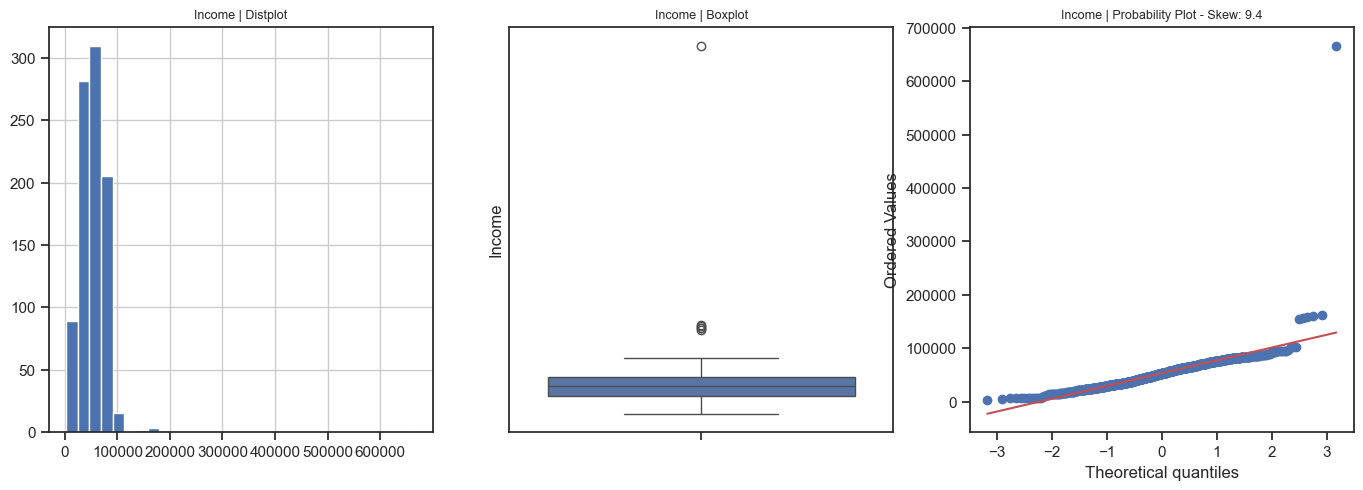

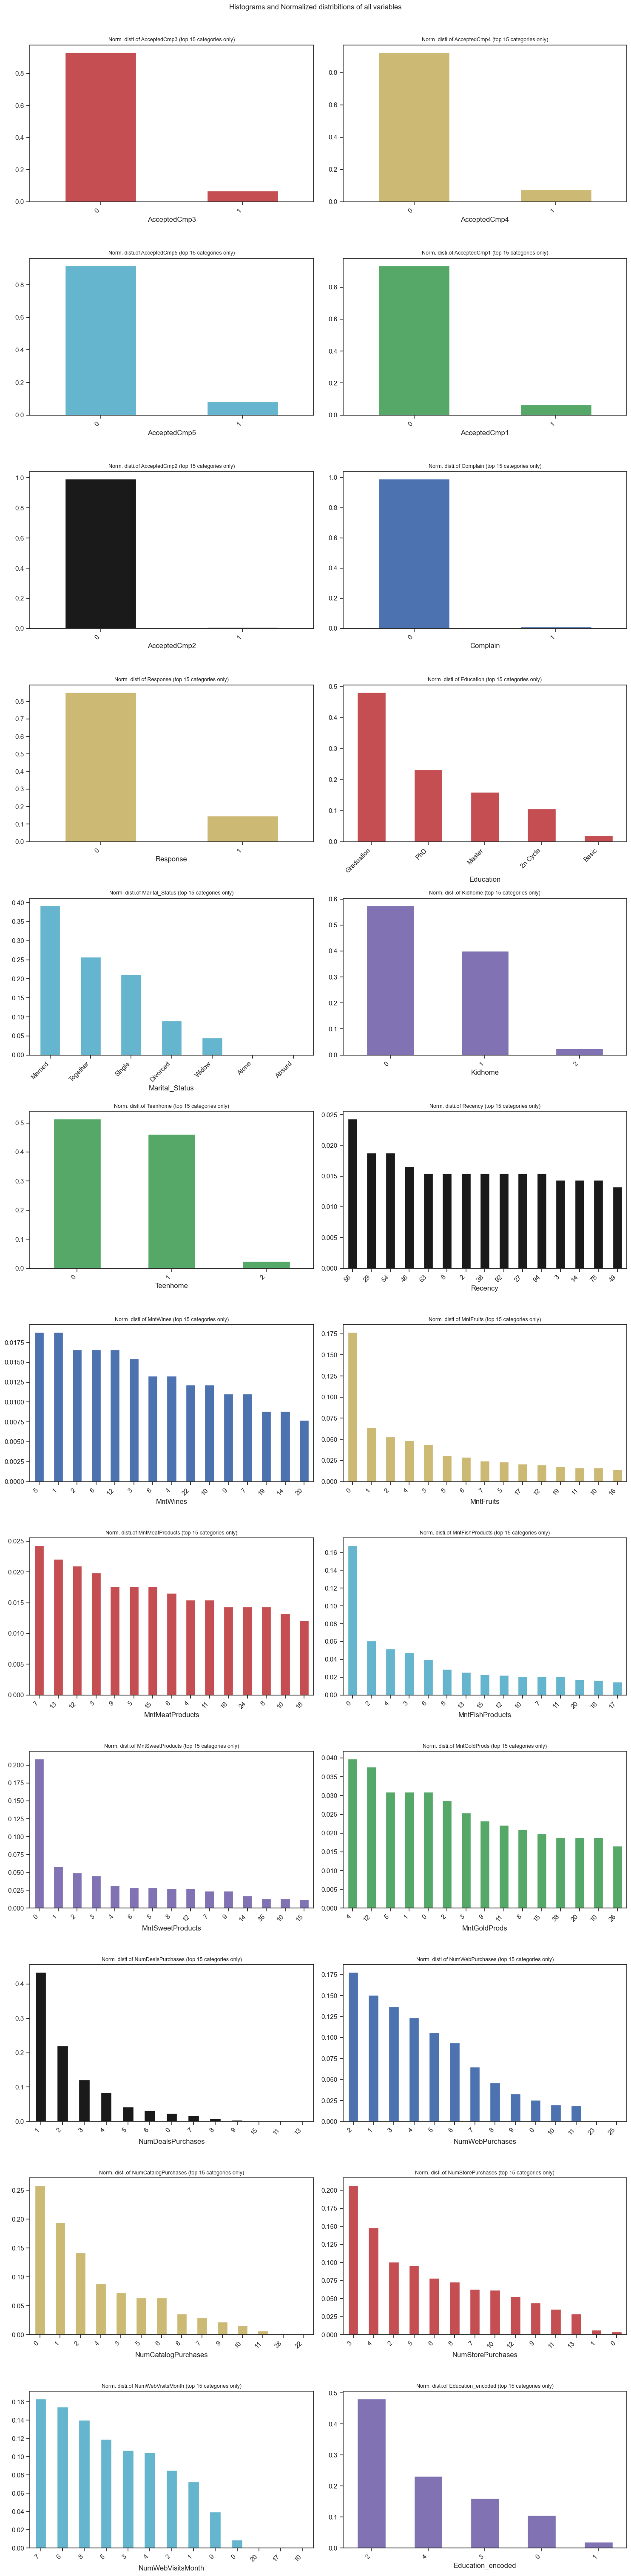

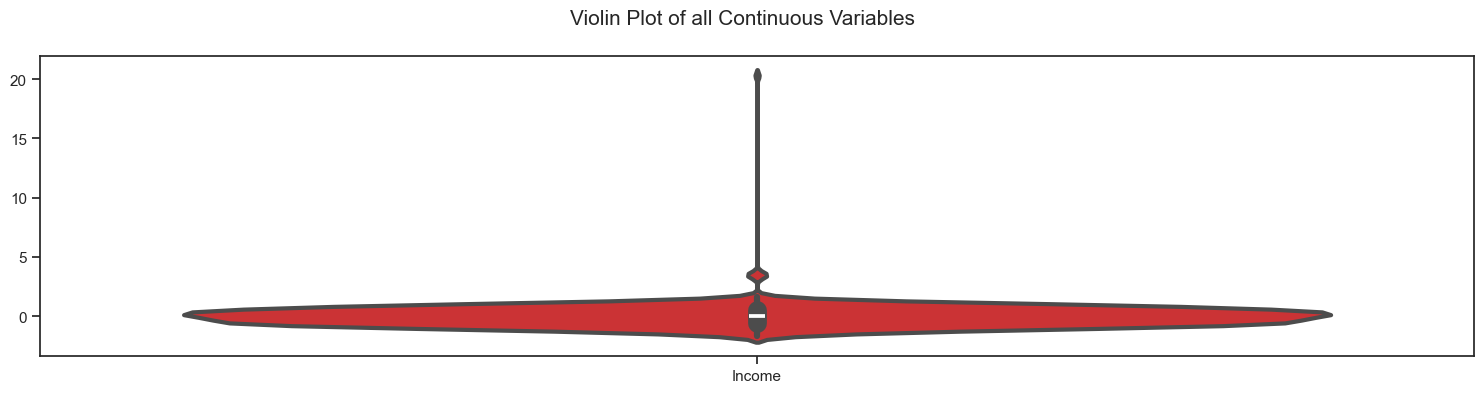

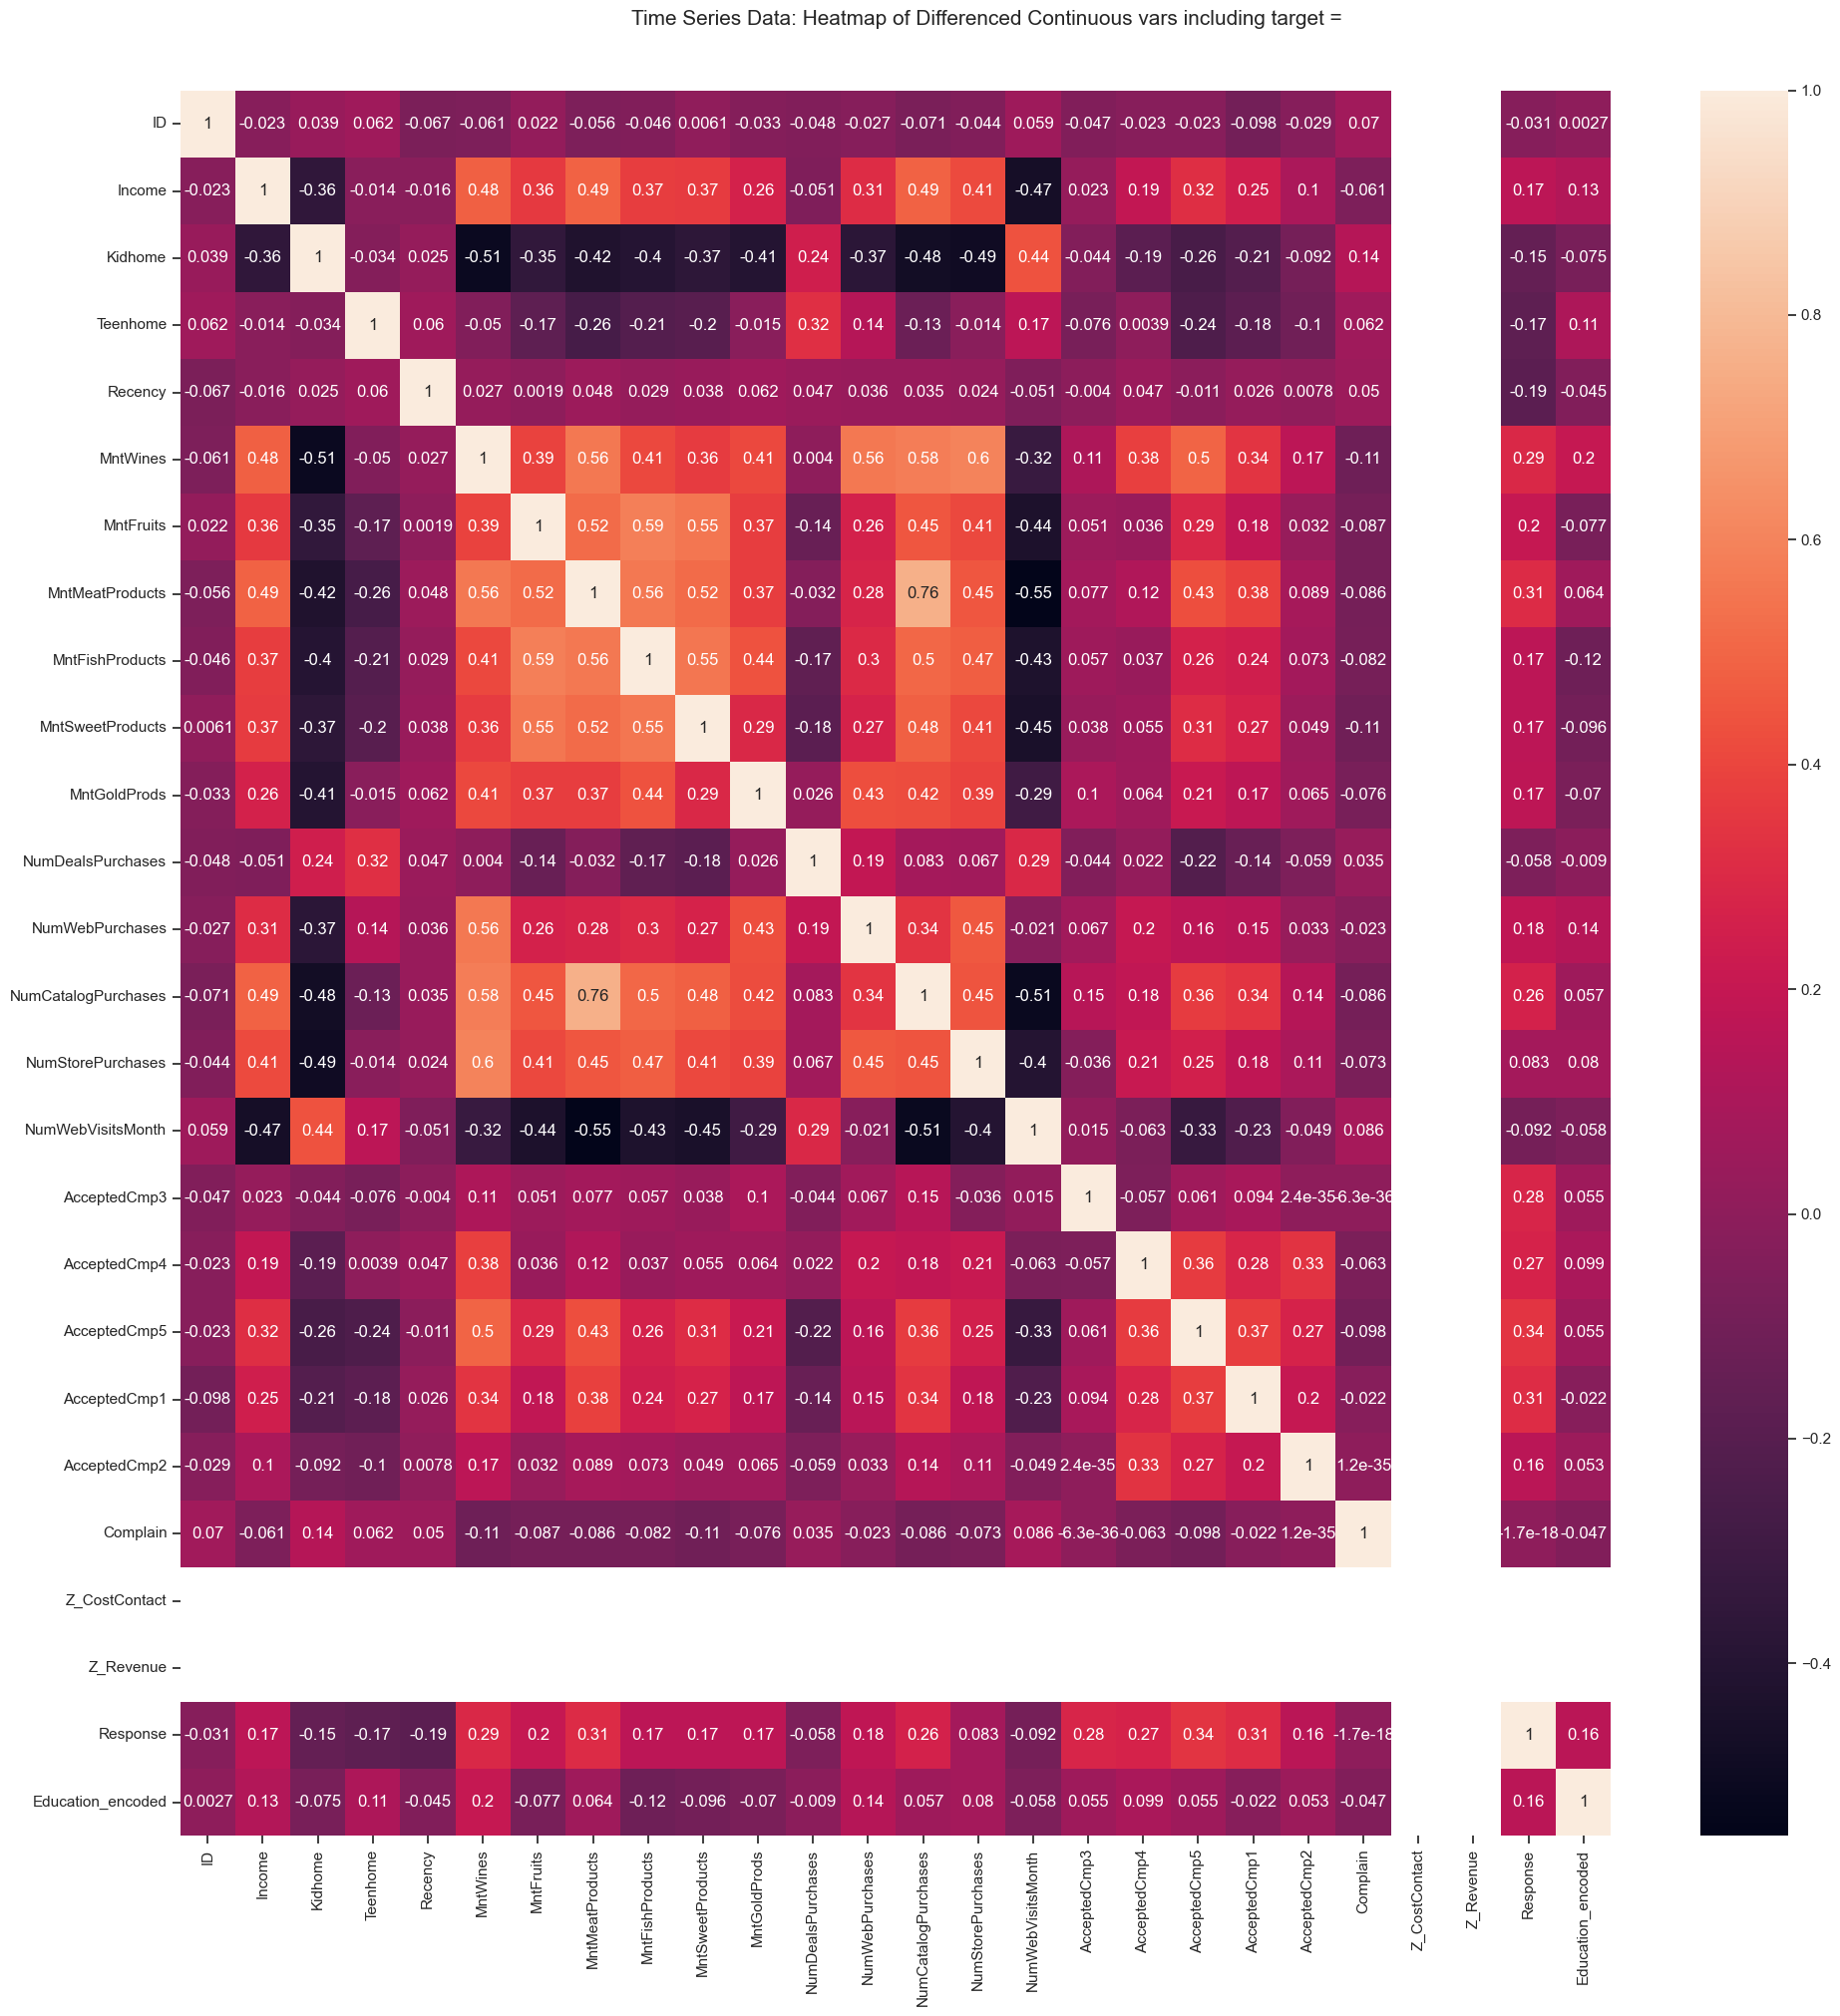

<Figure size 1500x0 with 0 Axes>

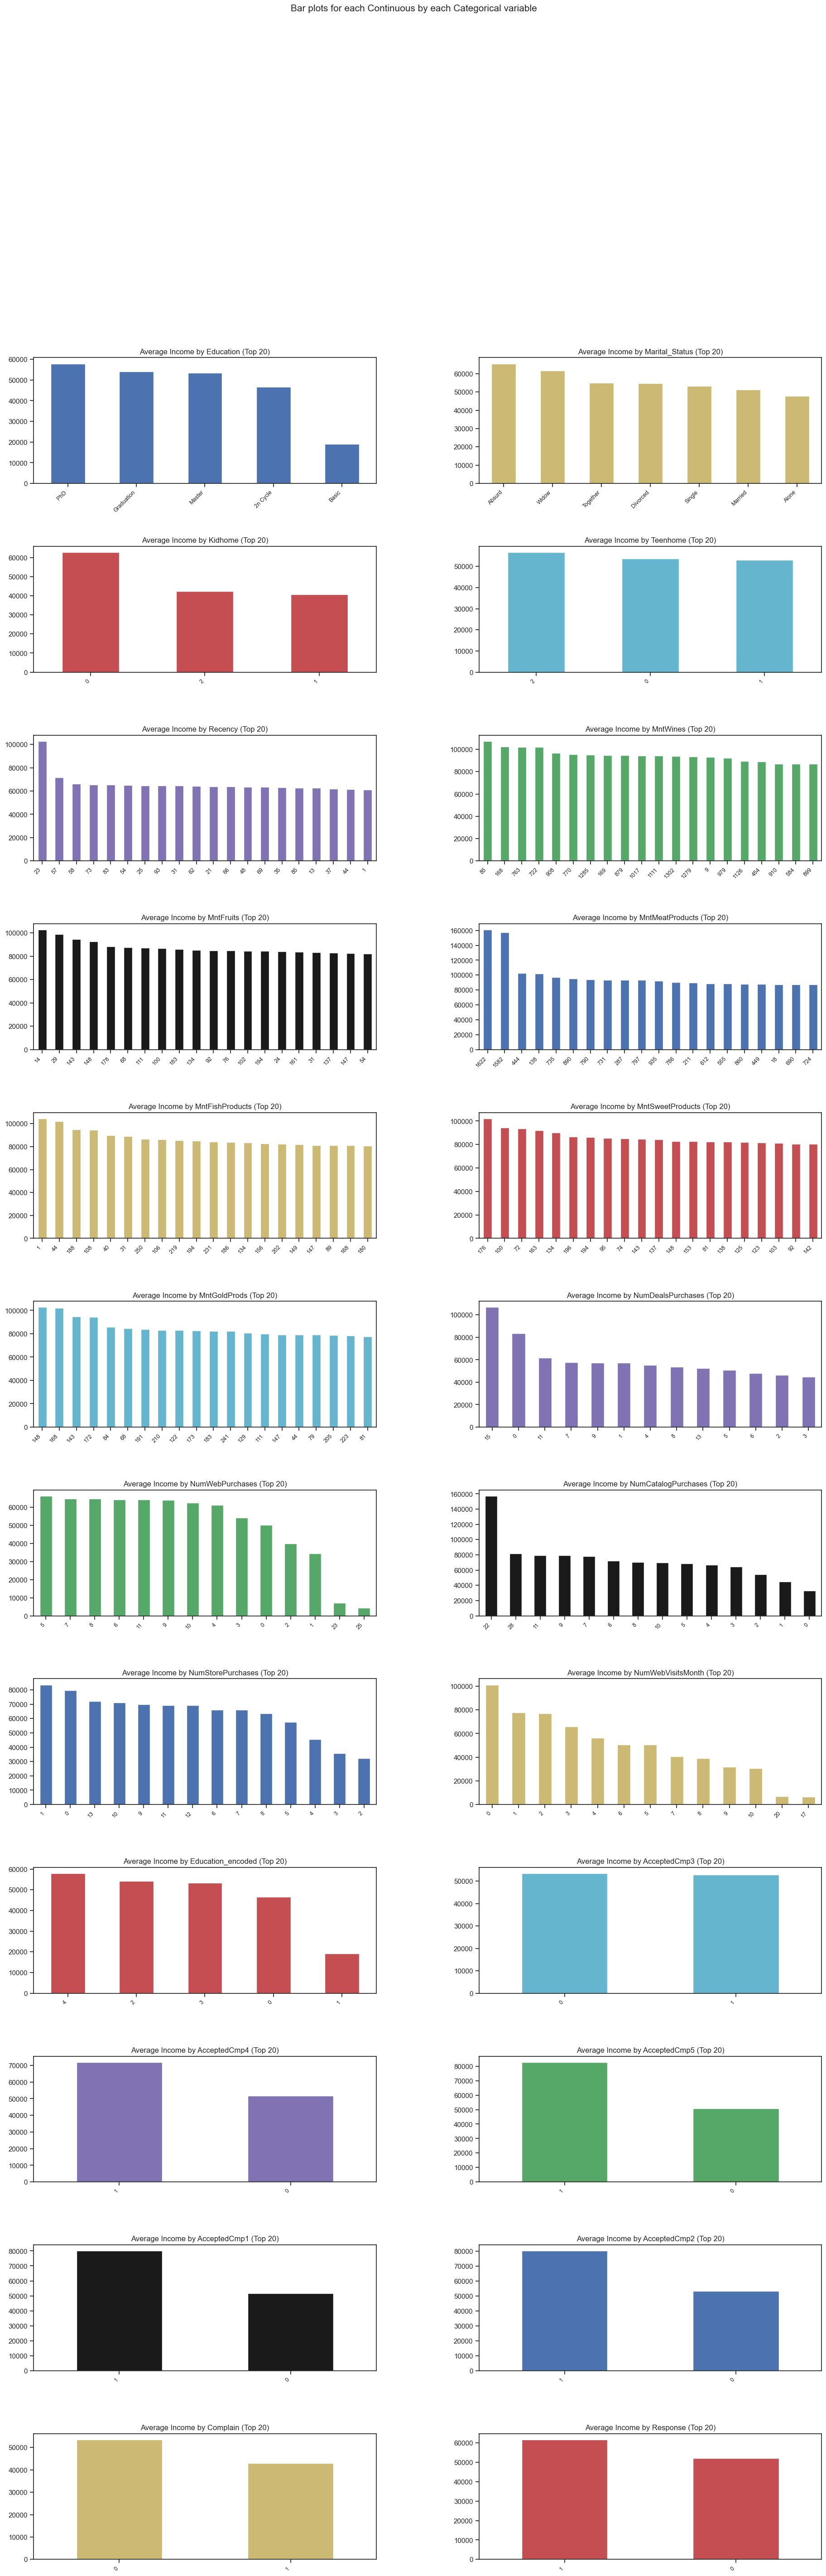

All Plots done
Time to run AutoViz = 9 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


In [12]:
%matplotlib inline
dft = AV.AutoViz(
    filename="",         # để trống nếu bạn truyền DataFrame
    dfte=df,             # DataFrame của bạn
    depVar="",      
    sep="\t", 
    header=0,
    verbose=1,
    lowess=False,
    chart_format="inline",
    max_rows_analyzed=50000,
    max_cols_analyzed=30,
)


Khi chạy, AutoViz sẽ:

- Liệt kê báo cáo chất lượng dữ liệu: số giá trị null, biến có hầu như không biến động, outliers, biến bị dư thừa.

- Cho mỗi biến số (“continuous”), vẽ histogram, box plot, scatter với biến mục tiêu nếu có.

- Cho các biến phân loại (“categorical”), vẽ biểu đồ tần suất (bar plot), so sánh nhóm theo biến mục tiêu.

- Vẽ ma trận tương quan (correlation heatmap) giữa các biến số.

- Nếu có biến ngày, có thể vẽ biểu đồ theo trend/series theo thời gian.

- Bố trí các đồ thị trong file HTML để bạn có thể xem tương tác, zoom, hover để xem chi tiết.

### **Phân tích đơn biến và hai biến**



#### **Phân tích đơn biến**

##### **Biến số (numeric)**

**# Income**


**Phân bố (Histogram):** Income phân bố lệch phải rõ rệt. Phần lớn giá trị tập trung ở mức thấp (dưới 100,000), tần suất cao nhất nằm gần 0. Tần suất giảm mạnh khi giá trị tăng, cho thấy sự bất đối xứng và có thể phản ánh bất bình đẳng thu nhập.

**Boxplot:** Có nhiều outliers (giá trị ngoại lai) ở phía cao. Điều này xác nhận rằng một số cá nhân có thu nhập vượt trội so với phần lớn còn lại. Median nằm khá thấp so với toàn bộ dải giá trị.

**Giá trị cụ thể:**

- Min: 0.00000

- Max: 6,666,660,000

- DQ Score: Không rõ con số cụ thể, nhưng có cảnh báo về giá trị vượt ngưỡng (ví dụ: vượt upper bound 1,428,583 hoặc thấp hơn lower bound 154,000), cho thấy dữ liệu có thể bị nhiễu hoặc cần xử lý.

**Nhận xét:** Biến Income có phân bố lệch phải mạnh, nhiều giá trị thấp và một số outliers rất cao. Điều này phản ánh sự chênh lệch thu nhập lớn trong tập dữ liệu. Cần kiểm tra kỹ các giá trị ngoại lai và xác minh tính hợp lệ của dữ liệu để tránh ảnh hưởng đến phân tích tiếp theo.

**# MntWines**


**Phân bố (Bar chart - Top 15 categories):**

- Biến này có giá trị rời rạc, đại diện cho số tiền chi tiêu cho rượu vang.

- Các giá trị phổ biến nhất là 5, 1, và 7, chiếm tỷ lệ phân bố cao nhất.

- Phân bố giảm dần từ các giá trị thấp đến cao, cho thấy xu hướng chi tiêu ít là phổ biến hơn.

**Giá trị nhỏ nhất và lớn nhất:**

- Theo hình dashboard, giá trị nhỏ nhất có thể là 0 hoặc gần 0.

- Giá trị lớn nhất trong top 15 là 20, nhưng có thể có giá trị cao hơn ngoài phạm vi hiển thị.

**Tính chất dữ liệu:**

- Dữ liệu có vẻ rời rạc, không liên tục.

- Không thấy outliers rõ ràng trong biểu đồ, nhưng cần kiểm tra thêm nếu có giá trị vượt ngưỡng.

**Nhận xét:** Biến MntWines phản ánh mức chi tiêu cho rượu vang, với phần lớn giá trị tập trung ở mức thấp (1–7). Phân bố lệch trái nhẹ, cho thấy đa số cá nhân chi tiêu ít, chỉ một số ít chi tiêu cao hơn. Dữ liệu rời rạc, phù hợp cho phân tích phân loại hoặc phân khúc khách hàng.

**# Recency**

**Phân bố (Bar chart - Top 15 categories):**

- Biến Recency có giá trị rời rạc, đại diện cho số ngày kể từ lần tương tác cuối cùng của khách hàng.

- Các giá trị phổ biến nhất là 56, 29, và 54, cho thấy phần lớn khách hàng tương tác gần đây trong khoảng này.

- Phân bố không đều, có xu hướng tập trung ở một số giá trị cụ thể, không trải đều toàn bộ dải.

**Giá trị nhỏ nhất và lớn nhất:**

- Theo bảng dashboard:

  - Min: 1

  - Max: 100

  - Có thể có nhiễu hoặc giá trị không hợp lệ (ví dụ: ratio = 0, noise xuất hiện), cần kiểm tra thêm.

**Tính chất dữ liệu:**

- Dữ liệu rời rạc, phù hợp với phân tích phân khúc hoặc hành vi khách hàng.

- Không thấy outliers rõ ràng, nhưng có thể có nhiễu do giá trị cực đại hoặc cực tiểu không hợp lý.

**Nhận xét:** Biến Recency phản ánh thời gian kể từ lần tương tác gần nhất của khách hàng, với phần lớn giá trị tập trung quanh mốc 29–56 ngày. Dữ liệu rời rạc, phân bố không đều, có thể dùng để phân khúc khách hàng theo mức độ tương tác gần đây. Cần kiểm tra thêm các giá trị nhiễu để đảm bảo độ tin cậy khi phân tích.

##### **Biến phân loại (categorical)**

**# Education_encoded**



**Phân loại & phân bố (Bar chart):**

- Biến này là biến phân loại đã được mã hóa số (encoded), gồm các nhóm: 0, 1, 2, 3, 4.

- Tần suất phân bố theo thứ tự giảm dần:

  - 2: chiếm tỷ lệ cao nhất (~45%)

  - 4: khoảng 25%

  - 3: khoảng 15%

  - 0: khoảng 10%

  - 1: thấp nhất, dưới 5%

- Điều này cho thấy nhóm mã hóa 2 là phổ biến nhất trong tập dữ liệu.

**Giá trị & cảnh báo dữ liệu:**

- Min: 0.000000

- Max: 4.000000

- Có cảnh báo: “Column has 0s. Since greater than upper bound (1.0), or lower than lower bound (0.0), cap them or remove them.” → Điều này cho thấy có thể có lỗi trong việc chuẩn hóa dữ liệu (ví dụ: nếu mô hình yêu cầu dữ liệu trong khoảng [0.0, 1.0] thì cần xử lý lại).

**Nhận xét:** Biến Education_encoded là biến phân loại đã được mã hóa số, với nhóm 2 chiếm tỷ lệ cao nhất. Phân bố không đều, phản ánh sự chênh lệch trong trình độ học vấn của mẫu dữ liệu. Tuy nhiên, có dấu hiệu dữ liệu vượt ngưỡng chuẩn hóa, cần kiểm tra và xử lý để đảm bảo phù hợp với mô hình phân tích hoặc học máy.

**# Response**


**Phân loại nhị phân:** gồm hai nhóm 0 và 1, tương ứng với phản hồi “Không” và “Có”.

**Phân bố dữ liệu:**

- Nhóm 0 chiếm gần 90% tổng số mẫu => rất phổ biến.

- Nhóm 1 chỉ chiếm khoảng 10% => rất ít phản hồi tích cực.

**Không có giá trị thiếu** => dữ liệu đầy đủ.

**Có cảnh báo về nhiễu (Noise)** trong bảng => cần kiểm tra kỹ để đảm bảo độ tin cậy khi dùng cho mô hình.

**Nhận xét:** Biến Response là biến phân loại nhị phân với phân bố mất cân bằng nghiêm trọng: phần lớn mẫu thuộc nhóm “Không phản hồi”. Dữ liệu đầy đủ nhưng có thể có nhiễu. Cần xử lý mất cân bằng trước khi đưa vào mô hình học máy để tránh sai lệch kết quả.

**# Complain**

**Phân loại nhị phân:**

- Gồm hai nhóm:

  - 0 – Không khiếu nại: chiếm khoảng 95.8%

  - 1 – Có khiếu nại: chỉ khoảng 4.2%

**Phân bố dữ liệu:**

- Biểu đồ cột cho thấy sự mất cân bằng nghiêm trọng giữa hai nhóm.

- Nhóm không khiếu nại áp đảo hoàn toàn, cho thấy phần lớn khách hàng không phản hồi tiêu cực.

**Chất lượng dữ liệu:**

- Không có giá trị thiếu.

- DQ Score tốt, không có vấn đề về nhiễu hay sai lệch.

**Nhận xét:** Biến Complain là biến phân loại nhị phân với tỷ lệ mất cân bằng rõ rệt: phần lớn khách hàng không khiếu nại. Điều này có thể phản ánh mức độ hài lòng cao hoặc xu hướng ít phản hồi tiêu cực. Dữ liệu đầy đủ, phù hợp để dùng trong phân tích churn hoặc mô hình dự đoán hành vi khách hàng, nhưng cần xử lý mất cân bằng nếu dùng cho học máy.

#### **Phân tích hai biến**

##### **# Biến số vs Biến số (Income vs MntWines)**

**Phân tích mối quan hệ giữa Income và MntWines:**
- **Biểu đồ “Average Income by MntWines”:**

  - Cho thấy xu hướng tăng dần của thu nhập trung bình theo mức chi tiêu rượu vang (MntWines).

  - Những nhóm có mức chi tiêu cao như 928, 1020, 1117, 1126 có thu nhập trung bình cao hơn rõ rệt so với các nhóm chi tiêu thấp như 9, 72, 85.

  - Điều này gợi ý một mối liên hệ phi tuyến: không phải cứ tăng một chút chi tiêu là thu nhập tăng đều, mà có thể có ngưỡng hoặc điểm bùng phát.

- **Đặc điểm phân bố của từng biến:**

  - Income: phân bố lệch phải, có nhiều outliers → biến này có độ phân tán lớn.

  - MntWines: phân bố rời rạc, tập trung ở mức chi tiêu thấp → biến này có thể phản ánh hành vi tiêu dùng.

**Nhận xét:** Có mối quan hệ phi tuyến tích cực giữa Income và MntWines: người có thu nhập cao có xu hướng chi tiêu nhiều hơn cho rượu vang. Tuy nhiên, do phân bố Income có nhiều outliers và MntWines là biến rời rạc, cần kiểm tra thêm bằng hồi quy phi tuyến hoặc phân tích phân khúc để xác nhận xu hướng này.

##### **# Biến phân loại vs Biến số (Education_encoded vs Income)**

**Phân tích mối quan hệ giữa Education_encoded và Income:**
- **Biểu đồ “Average Income by Education_encoded”:**

    - Nhóm Education_encoded = 4 có thu nhập trung bình cao nhất (gần 60,000).

    - Nhóm 2 và 3 có thu nhập trung bình khá cao, lần lượt đứng thứ hai và ba.

    - Nhóm 0 có thu nhập trung bình thấp hơn rõ rệt.

    - Nhóm 1 có thu nhập thấp nhất trong tất cả các nhóm.

- **Xu hướng tổng thể:**

    - Có mối liên hệ tuyến tính yếu hoặc phi tuyến nhẹ: trình độ học vấn cao hơn (mã hóa lớn hơn) thường đi kèm với thu nhập cao hơn.

    - Tuy nhiên, không phải lúc nào mã hóa cao hơn cũng đồng nghĩa với thu nhập cao hơn tuyệt đối (ví dụ: nhóm 2 cao hơn nhóm 3).

- **Phân bố Education_encoded:**

    - Nhóm 2 chiếm tỷ lệ lớn nhất trong dữ liệu => có thể ảnh hưởng đến trung bình tổng thể.

    - Nhóm 1 rất ít => cần cẩn trọng khi phân tích thống kê.

**Nhận xét:** Có mối quan hệ tích cực giữa trình độ học vấn (Education_encoded) và thu nhập (Income): nhóm có trình độ học vấn cao hơn thường có thu nhập trung bình cao hơn. Tuy nhiên, mối quan hệ này không hoàn toàn tuyến tính và có thể bị ảnh hưởng bởi phân bố không đều giữa các nhóm. Cần kiểm tra thêm bằng hồi quy hoặc kiểm định thống kê để xác nhận mức độ ảnh hưởng.

##### **# Biến phân loại vs Biến phân loại (Response vs Complain)**

In [3]:
# Bổ sung bảng chéo cross-tab để phân tích
import pandas as pd

# Đọc dữ liệu
df = pd.read_csv("dataset/marketing_campaign.csv", sep="\t")

# Tạo bảng chéo giữa Response và Complain
cross_tab = pd.crosstab(df['Complain'], df['Response'], normalize='index')

# Hiển thị bảng chéo
print(cross_tab)

Response         0         1
Complain                    
0         0.850834  0.149166
1         0.857143  0.142857


**Phân tích mối quan hệ:**
- **Phân bố gần như tương đương giữa hai nhóm Complain:**

    - Nhóm không khiếu nại (Complain = 0) có tỷ lệ phản hồi là 14.92%.

    - Nhóm có khiếu nại (Complain = 1) có tỷ lệ phản hồi là 14.29%.

- **Không có sự khác biệt rõ rệt về tỷ lệ phản hồi giữa hai nhóm.**

    - Dữ liệu cho thấy tỷ lệ phản hồi gần như bằng nhau.

- **Phân bố mất cân bằng vẫn tồn tại ở cả hai biến, nhưng mối liên hệ hành vi giữa Complain và Response là yếu hoặc không đáng kể.**

**Nhận xét:** Phân tích bảng chéo cho thấy không có mối liên hệ rõ ràng giữa việc khiếu nại (Complain) và phản hồi (Response). Tỷ lệ phản hồi giữa hai nhóm gần như tương đương (~15%), cho thấy hành vi phản hồi không bị ảnh hưởng đáng kể bởi việc khiếu nại. Do đó, biến Complain có thể không phải là yếu tố dự báo mạnh cho biến Response trong mô hình hành vi khách hàng.

## **Hạn chế & lưu ý khi dùng AutoViz**

- Vì AutoViz cố gắng vẽ rất nhiều đồ thị, nếu dataset có rất nhiều cột hoặc rất nhiều hàng, nó có thể chậm hoặc quá tải. Bạn nên dùng giới hạn max_rows_analyzed và max_cols_analyzed. 

- AutoViz tự chọn loại đồ thị, nhưng đôi khi không phù hợp với mục đích đặc thù bạn muốn (ví dụ muốn xem phân phối log, hoặc muốn đồ thị tùy chỉnh). Trong những trường hợp đó, bạn vẫn cần viết code thủ công với seaborn / matplotlib.

- Nếu dữ liệu có biến rất nhiều giá trị (categorical với hàng trăm mục), AutoViz có thể không hiển thị hết (có thể bỏ qua hoặc phân nhóm).

- Đôi khi kết nối giữa biến mục tiêu và biến số yếu, đồ thị mặc định có thể không rõ ràng — bạn cần lọc hoặc zoom vào vùng quan tâm.

- AutoViz phụ thuộc vào các thư viện vẽ như matplotlib, hvPlot, bokeh, v.v. — nếu môi trường chưa hỗ trợ (như môi trường không có GUI), có thể gặp lỗi.